In [1]:
# Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from scipy import stats

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"
classes = ['open_eyes', 'closed_eyes']

print("Libraries imported!")

Libraries imported!


Small  (<=70px) : 434 images
Medium (71-110) : 6759 images
Large  (>110px) : 2271 images


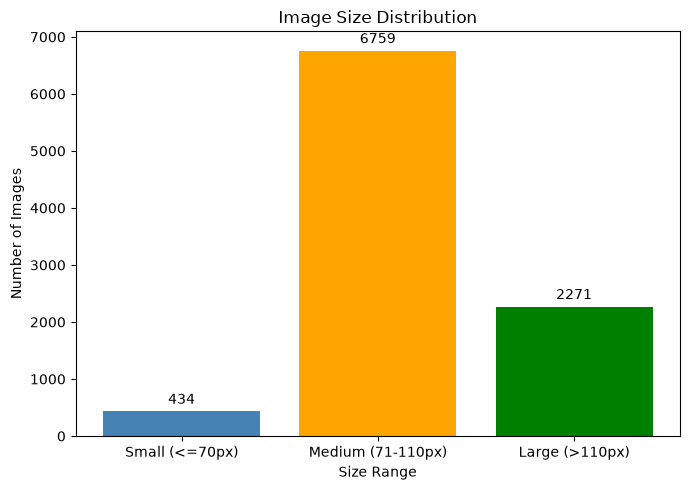

In [2]:
# Size Distribution

import os
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"

sizes = []

# Collect all image sizes
for class_name in ['open_eyes', 'closed_eyes']:
    class_path = os.path.join(processed_path, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        sizes.append(img.size[0])  # Width only since all are square

# Group sizes into ranges
small  = sum(1 for s in sizes if s <= 70)
medium = sum(1 for s in sizes if 71 <= s <= 110)
large  = sum(1 for s in sizes if s > 110)

print(f"Small  (<=70px) : {small} images")
print(f"Medium (71-110) : {medium} images")
print(f"Large  (>110px) : {large} images")

# Plot
labels = ['Small (<=70px)', 'Medium (71-110px)', 'Large (>110px)']
values = [small, medium, large]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=['steelblue', 'orange', 'green'])
ax.set_title('Image Size Distribution')
ax.set_xlabel('Size Range')
ax.set_ylabel('Number of Images')
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

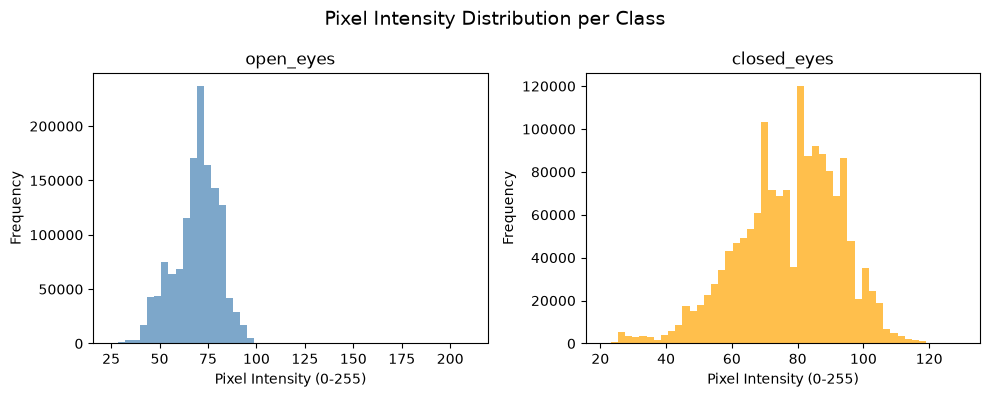

In [3]:
#Pixel intensity histogram

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"

classes = ['open_eyes', 'closed_eyes']
colors = ['steelblue', 'orange']

plt.figure(figsize=(10, 4))

# Plot pixel intensity histogram for each class
for idx, class_name in enumerate(classes):
    class_path = os.path.join(processed_path, class_name)
    pixel_values = []

    # Collect pixel values from 200 random images
    images = os.listdir(class_path)[:200]
    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert('L')
        pixel_values.extend(np.array(img).flatten())

    plt.subplot(1, 2, idx + 1)
    plt.hist(pixel_values, bins=50, color=colors[idx], alpha=0.7)
    plt.title(f'{class_name}')
    plt.xlabel('Pixel Intensity (0-255)')
    plt.ylabel('Frequency')

plt.suptitle('Pixel Intensity Distribution per Class', fontsize=14)
plt.tight_layout()
plt.show()

Class balance:
  open_eyes: 4399 images (46.48%)
  closed_eyes: 5065 images (53.52%)


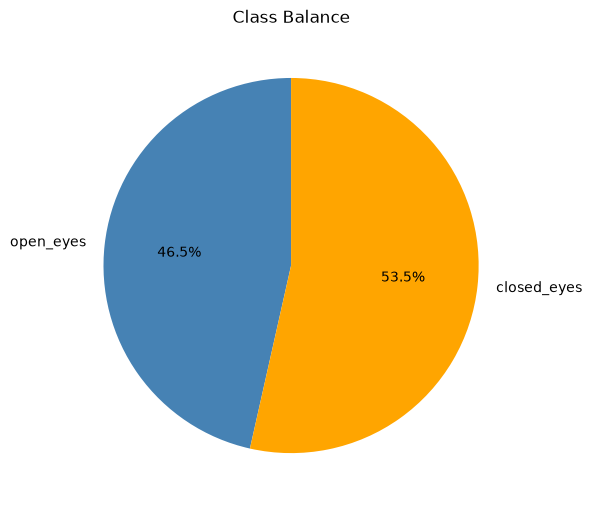

In [4]:
#Class balance pie chart

import os
import matplotlib.pyplot as plt

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"

classes = ['open_eyes', 'closed_eyes']
counts = []

for class_name in classes:
    class_path = os.path.join(processed_path, class_name)
    counts.append(len(os.listdir(class_path)))

total = sum(counts)
percentages = [round((c / total) * 100, 2) for c in counts]

print("Class balance:")
for c, count, pct in zip(classes, counts, percentages):
    print(f"  {c}: {count} images ({pct}%)")

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(percentages, labels=classes, autopct='%1.1f%%',
        colors=['steelblue', 'orange'], startangle=90)
plt.title('Class Balance')
plt.tight_layout()
plt.show()

In [5]:
#Mean, Median, Mode, Std Dev

import os
import numpy as np
from PIL import Image
from scipy import stats

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\MRL Model\Data\processed"

classes = ['open_eyes', 'closed_eyes']

# Calculate statistics per class
for class_name in classes:
    class_path = os.path.join(processed_path, class_name)
    pixel_values = []

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert('L')
        pixel_values.extend(np.array(img).flatten())

    pixel_values = np.array(pixel_values)

    mean   = np.mean(pixel_values)
    median = np.median(pixel_values)
    mode   = stats.mode(pixel_values, keepdims=True)[0][0]
    std    = np.std(pixel_values)

    print(f"\n--- {class_name.upper()} ---")
    print(f"  Mean   : {mean:.2f}")
    print(f"  Median : {median:.2f}")
    print(f"  Mode   : {mode}")
    print(f"  Std Dev: {std:.2f}")


--- OPEN_EYES ---
  Mean   : 88.63
  Median : 82.00
  Mode   : 72
  Std Dev: 41.92

--- CLOSED_EYES ---
  Mean   : 98.73
  Median : 91.00
  Mode   : 76
  Std Dev: 32.22


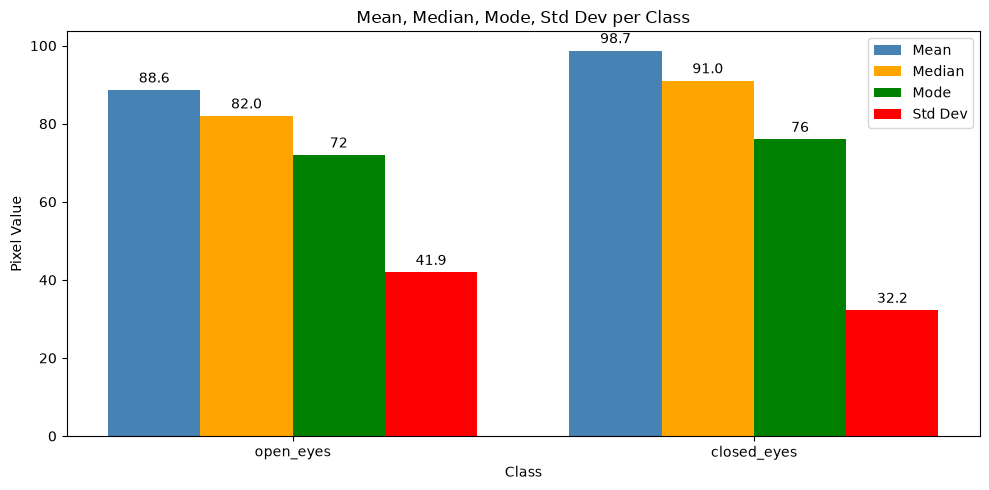

In [6]:
#barchart

import matplotlib.pyplot as plt
import numpy as np

classes = ['open_eyes', 'closed_eyes']
means   = [88.63, 98.73]
medians = [82.00, 91.00]
modes   = [72, 76]
stds    = [41.92, 32.22]

x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - 1.5*width, means,   width, label='Mean',    color='steelblue')
bars2 = ax.bar(x - 0.5*width, medians, width, label='Median',  color='orange')
bars3 = ax.bar(x + 0.5*width, modes,   width, label='Mode',    color='green')
bars4 = ax.bar(x + 1.5*width, stds,    width, label='Std Dev', color='red')

ax.set_xlabel('Class')
ax.set_ylabel('Pixel Value')
ax.set_title('Mean, Median, Mode, Std Dev per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(bars1, padding=3, fmt='%.1f')
ax.bar_label(bars2, padding=3, fmt='%.1f')
ax.bar_label(bars3, padding=3)
ax.bar_label(bars4, padding=3, fmt='%.1f')

plt.tight_layout()
plt.show()


--- OPEN_EYES ---
  Skewness: 1.0964
  Positive skew - pixels mostly dark, tail on right

--- CLOSED_EYES ---
  Skewness: 0.7202
  Positive skew - pixels mostly dark, tail on right


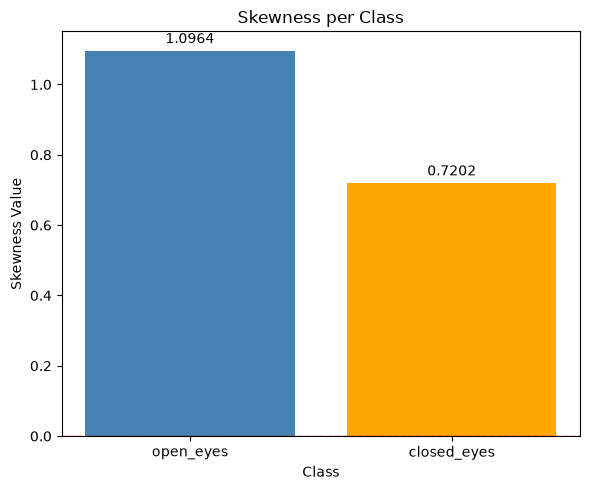

In [7]:
#skewness

from scipy.stats import skew

skewness_values = []

for class_name in classes:
    class_path = os.path.join(processed_path, class_name)
    pixel_values = []
    for img_name in os.listdir(class_path):
        img = Image.open(os.path.join(class_path, img_name)).convert('L')
        pixel_values.extend(np.array(img).flatten())

    pixel_values = np.array(pixel_values)
    skewness = skew(pixel_values)
    skewness_values.append(skewness)

    print(f"\n--- {class_name.upper()} ---")
    print(f"  Skewness: {skewness:.4f}")
    if skewness > 0:
        print(f"  Positive skew - pixels mostly dark, tail on right")
    elif skewness < 0:
        print(f"  Negative skew - pixels mostly bright, tail on left")
    else:
        print(f"  Symmetric distribution")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(classes, skewness_values, color=['steelblue', 'orange'])
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax.set_title('Skewness per Class')
ax.set_xlabel('Class')
ax.set_ylabel('Skewness Value')
ax.bar_label(bars, padding=3, fmt='%.4f')
plt.tight_layout()
plt.show()